<a href="https://colab.research.google.com/github/PrachiKumar298/MLLab/blob/main/lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Cancer**

In [39]:
import pandas as pd

data_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data'

column_names = [
    'id', 'diagnosis',
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
    'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean',
    'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
    'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
    'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
    'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst',
    'symmetry_worst', 'fractal_dimension_worst'
]

bc_df = pd.read_csv(data_url, names=column_names)

bc_df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
from sklearn.model_selection import train_test_split

X_bc = bc_df.drop(['id', 'diagnosis'], axis=1)
y_bc = bc_df['diagnosis']

X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(X_bc, y_bc, test_size=0.25, random_state=42)

print("Shape of X_train_bc:", X_train_bc.shape)
print("Shape of X_test_bc:", X_test_bc.shape)
print("Shape of y_train_bc:", y_train_bc.shape)
print("Shape of y_test_bc:", y_test_bc.shape)

Shape of X_train_bc: (426, 30)
Shape of X_test_bc: (143, 30)
Shape of y_train_bc: (426,)
Shape of y_test_bc: (143,)


SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

svm_model_bc_proba = SVC(random_state=42, probability=True)

svm_model_bc_proba.fit(X_train_bc, y_train_bc)

y_pred_bc_proba = svm_model_bc_proba.predict(X_test_bc)

accuracy_bc_proba = accuracy_score(y_test_bc, y_pred_bc_proba)
print(f"SVM Model Accuracy for Breast Cancer (with probability enabled): {accuracy_bc_proba:.2f}")

SVM Model Accuracy for Breast Cancer (with probability enabled): 0.95


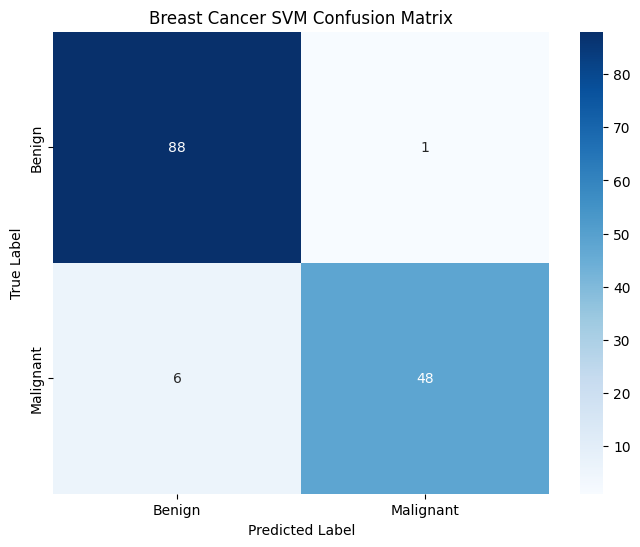

In [ ]:

cm_bc = confusion_matrix(y_test_bc, y_pred_bc_proba)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_bc, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Breast Cancer SVM Confusion Matrix')
plt.show()

In [ ]:

report_bc = classification_report(y_test_bc, y_pred_bc_proba, target_names=['Benign', 'Malignant'])
print(report_bc)

              precision    recall  f1-score   support

      Benign       0.94      0.99      0.96        89
   Malignant       0.98      0.89      0.93        54

    accuracy                           0.95       143
   macro avg       0.96      0.94      0.95       143
weighted avg       0.95      0.95      0.95       143



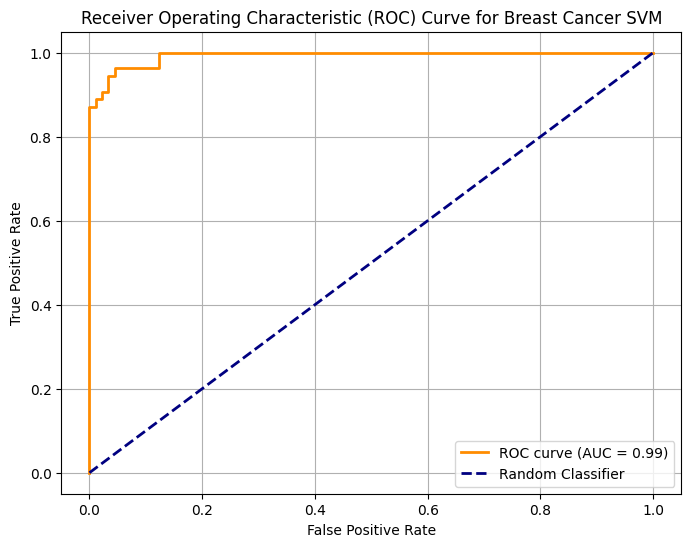

In [ ]:

y_proba_bc = svm_model_bc_proba.predict_proba(X_test_bc)


y_test_bc_binary = (y_test_bc == 'M').astype(int)

fpr_bc, tpr_bc, _ = roc_curve(y_test_bc_binary, y_proba_bc[:, 1])
roc_auc_bc = auc(fpr_bc, tpr_bc)

plt.figure(figsize=(8, 6))
plt.plot(fpr_bc, tpr_bc, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_bc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Breast Cancer SVM')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


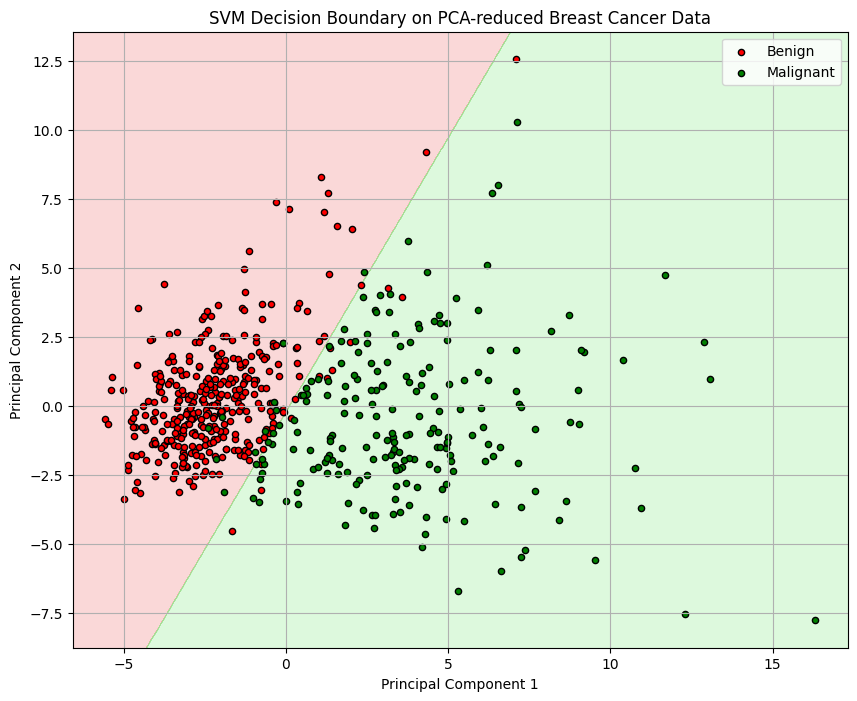

In [ ]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import numpy as np

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_bc_scaled = scaler.fit_transform(X_bc)

pca = PCA(n_components=2)
X_bc_pca = pca.fit_transform(X_bc_scaled)

bc_pca_df = pd.DataFrame(data=X_bc_pca, columns=['principal_component_1', 'principal_component_2'])
bc_pca_df['diagnosis'] = y_bc.reset_index(drop=True)

y_bc_pca_numeric = (bc_pca_df['diagnosis'] == 'M').astype(int)

X_train_bc_pca, X_test_bc_pca, y_train_bc_pca, y_test_bc_pca = train_test_split(
    bc_pca_df[['principal_component_1', 'principal_component_2']], y_bc_pca_numeric, test_size=0.25, random_state=42
)

svm_model_pca = SVC(kernel='linear', random_state=42)
svm_model_pca.fit(X_train_bc_pca, y_train_bc_pca)

x_min, x_max = X_bc_pca[:, 0].min() - 1, X_bc_pca[:, 0].max() + 1
y_min, y_max = X_bc_pca[:, 1].min() - 1, X_bc_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = svm_model_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(('lightcoral', 'lightgreen')))

colors = ['red', 'green']
for i, target_name in enumerate(['Benign', 'Malignant']):
    plt.scatter(X_bc_pca[y_bc_pca_numeric == i, 0],
                X_bc_pca[y_bc_pca_numeric == i, 1],
                c=colors[i], label=target_name, s=20, edgecolor='k')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('SVM Decision Boundary on PCA-reduced Breast Cancer Data')
plt.legend()
plt.grid(True)
plt.show()

KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
knn_model_bc = KNeighborsClassifier(n_neighbors=5)

knn_model_bc.fit(X_train_bc, y_train_bc)

y_pred_knn_bc = knn_model_bc.predict(X_test_bc)

accuracy_knn_bc = accuracy_score(y_test_bc, y_pred_knn_bc)
print(f"KNN Model Accuracy for Breast Cancer dataset: {accuracy_knn_bc:.2f}")

KNN Model Accuracy for Breast Cancer dataset: 0.97


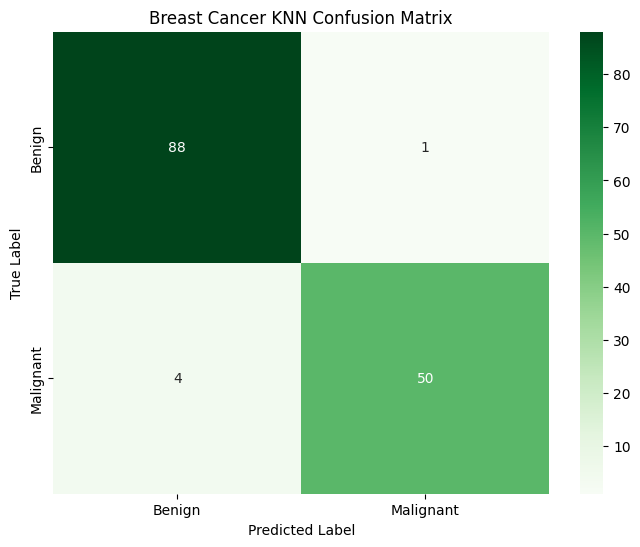

In [ ]:
cm_knn_bc = confusion_matrix(y_test_bc, y_pred_knn_bc)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn_bc, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Breast Cancer KNN Confusion Matrix')
plt.show()

In [ ]:
report_knn_bc = classification_report(y_test_bc, y_pred_knn_bc, target_names=['Benign', 'Malignant'])
print(report_knn_bc)

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        89
   Malignant       0.98      0.93      0.95        54

    accuracy                           0.97       143
   macro avg       0.97      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143



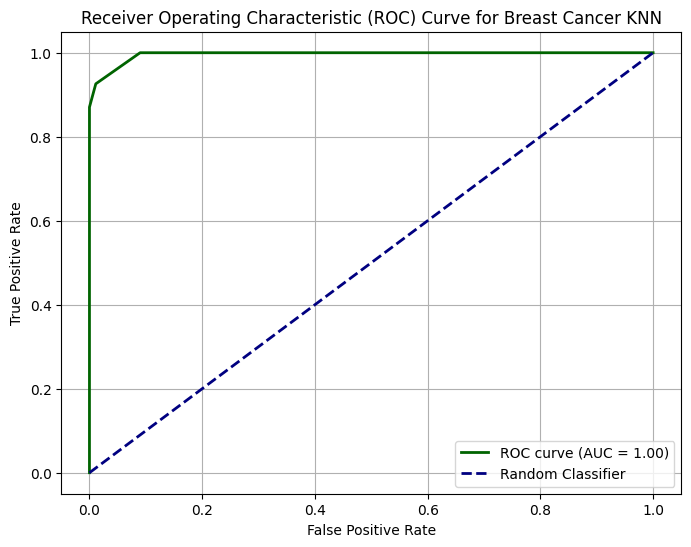

In [ ]:

y_proba_knn_bc = knn_model_bc.predict_proba(X_test_bc)

y_test_bc_binary = (y_test_bc == 'M').astype(int)

fpr_knn_bc, tpr_knn_bc, _ = roc_curve(y_test_bc_binary, y_proba_knn_bc[:, 1])
roc_auc_knn_bc = auc(fpr_knn_bc, tpr_knn_bc)

plt.figure(figsize=(8, 6))
plt.plot(fpr_knn_bc, tpr_knn_bc, color='darkgreen', lw=2, label=f'ROC curve (AUC = {roc_auc_knn_bc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Breast Cancer KNN')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Comparison



,Dataset,Model,Metric,Accuracy
0,Breast Cancer,SVM,Training,0.910798
1,Breast Cancer,SVM,Testing,0.951049
2,Breast Cancer,KNN,Training,0.934272
3,Breast Cancer,KNN,Testing,0.965035


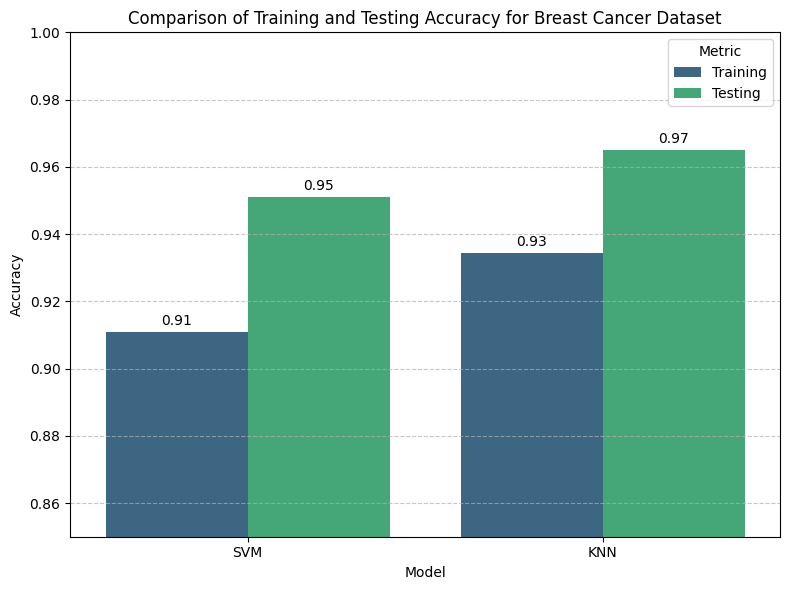

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
y_pred_train_bc_svm = svm_model_bc_proba.predict(X_train_bc)
accuracy_train_bc_svm = accuracy_score(y_train_bc, y_pred_train_bc_svm)

y_pred_train_bc_knn = knn_model_bc.predict(X_train_bc)
accuracy_train_bc_knn = accuracy_score(y_train_bc, y_pred_train_bc_knn)

accuracy_data_bc = {
    'Dataset': [
        'Breast Cancer', 'Breast Cancer', 'Breast Cancer', 'Breast Cancer'
    ],
    'Model': [
        'SVM', 'SVM', 'KNN', 'KNN'
    ],
    'Metric': [
        'Training', 'Testing', 'Training', 'Testing'
    ],
    'Accuracy': [
        accuracy_train_bc_svm, accuracy_bc_proba, accuracy_train_bc_knn, accuracy_knn_bc
    ]
}

accuracy_df_bc = pd.DataFrame(accuracy_data_bc)
display(accuracy_df_bc)

plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='Accuracy', hue='Metric', data=accuracy_df_bc,
            palette='viridis', errorbar=None)

plt.title('Comparison of Training and Testing Accuracy for Breast Cancer Dataset')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.85, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Metric')

for container in plt.gca().containers:
    for bar in container:
        height = bar.get_height()
        plt.gca().annotate(f'{height:.2f}',
                           xy=(bar.get_x() + bar.get_width() / 2, height),
                           xytext=(0, 3),  # 3 points vertical offset
                           textcoords="offset points",
                           ha='center', va='bottom')

plt.tight_layout()
plt.show()

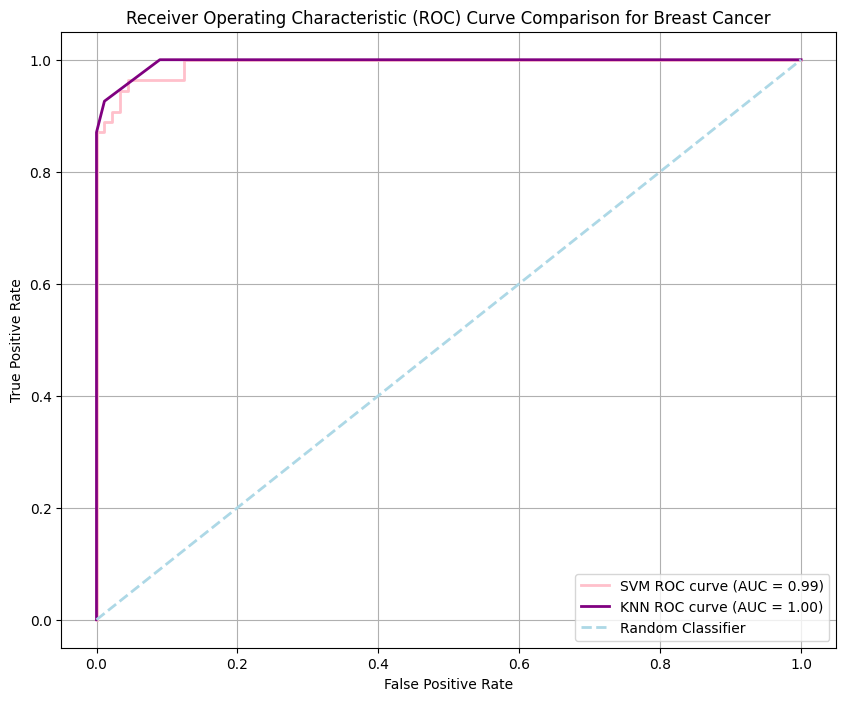

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_test_bc_binary = (y_test_bc == 'M').astype(int)

fpr_bc, tpr_bc, _ = roc_curve(y_test_bc_binary, y_proba_bc[:, 1])
roc_auc_bc = auc(fpr_bc, tpr_bc)

fpr_knn_bc, tpr_knn_bc, _ = roc_curve(y_test_bc_binary, y_proba_knn_bc[:, 1])
roc_auc_knn_bc = auc(fpr_knn_bc, tpr_knn_bc)

plt.figure(figsize=(10, 8))

plt.plot(fpr_bc, tpr_bc, color='pink', lw=2, label=f'SVM ROC curve (AUC = {roc_auc_bc:.2f})')

plt.plot(fpr_knn_bc, tpr_knn_bc, color='purple', lw=2, label=f'KNN ROC curve (AUC = {roc_auc_knn_bc:.2f})')

plt.plot([0, 1], [0, 1], color='lightblue', lw=2, linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison for Breast Cancer')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Comparison of Confusion Matrices (SVM vs. KNN) for Breast Cancer

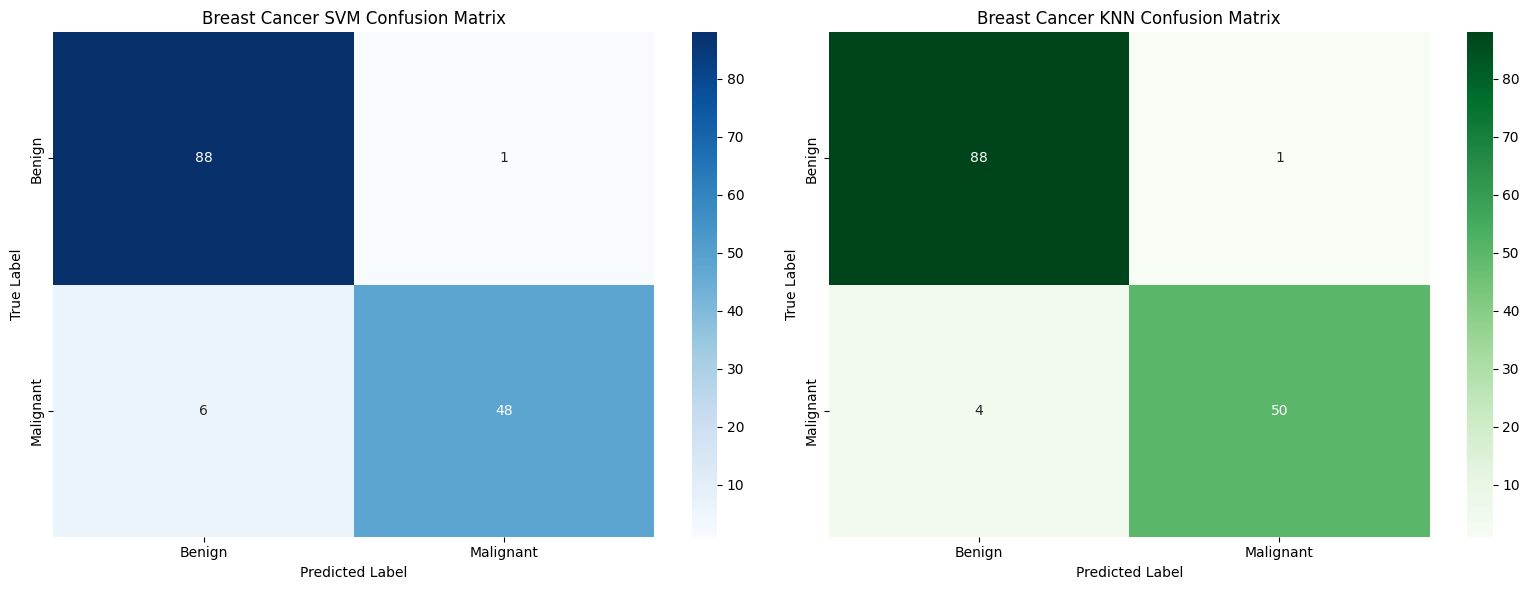

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.heatmap(cm_bc, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Breast Cancer SVM Confusion Matrix')

plt.subplot(1, 2, 2)
sns.heatmap(cm_knn_bc, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Breast Cancer KNN Confusion Matrix')

plt.tight_layout()
plt.show()